# How to read one of the zarr stores and grab a stack item

In [1]:
import xarray as xr
from pystac_client import Client
import rasterio
from rasterio.plot import show
import planetary_computer as pc

Pretty straight forward with xarray. These zarr stores are also zarr v3. So I imagine you need that installed in your environment

In [2]:
zarr_path = "C:/Users/m337l400/Documents/surface_lakes/supraglacial_lake_id/test_masks/lake_detection_binary_masks_TEST.zarr" #'../lake_detection_binary_masks_2019.zarr'
#lake_zarr = xr.open_dataset(zarr_path)
lake_zarr = xr.open_dataset(zarr_path, engine="zarr", chunks={})

The dataset has a bit of text in the attributes. The main two variables are `ndwi_mask` and `source_items`.

`ndwi_mask`: A binary datacube of NDWI>0.3

`source_items`: The stac_ids used in the `ndwi_mask`

In [3]:
lake_zarr

<xarray.Dataset> Size: 12GB
Dimensions:       (time: 9, y: 52904, x: 26088, stac_item: 4)
Coordinates:
  * time          (time) datetime64[ns] 72B 2019-05-01 2019-05-02 ... 2019-05-10
  * y             (y) float64 423kB -1.944e+06 -1.944e+06 ... -2.473e+06
  * x             (x) float64 209kB -2.577e+05 -2.577e+05 ... 3.205e+03
Dimensions without coordinates: stac_item
Data variables:
    ndwi_mask     (time, y, x) int8 12GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    source_items  (time, stac_item) |S64 2kB dask.array<chunksize=(1, 4), meta=np.ndarray>
    spatial_ref   int64 8B ...
Attributes:
    crs:                       EPSG:3413
    description:               ~Daily NDWI masks clipped to Greenland ice she...
    resolution_m:              10
    cloud_percentage_filter:   10%
    ice_sheet_masks:           https://www.doi.org/10.5067/579TO87M7IZB
    ice_sheet_masks_citation:  Greene, C.A., Gardner, A.S., Wood, M. et al. U...

Now to grab a stac item from `source_items` and read an image. The `source_items` variable as all the ids that were used in the merge

In [46]:
from pystac_client import Client
import numpy as np

catalog = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1",modifier=pc.sign_inplace)
#item_id = lake_zarr['source_items'].isel(time=2).data[0].decode('utf-8') # make sure to decode the string. Not sure the best way to store these
item_id = np.char.decode(lake_zarr['source_items'].isel(time=0).data[0]) # decode wasnt working so I did this instead
collection = catalog.get_collection("sentinel-2-l2a")
item = collection.get_item(item_id) 
item

<Item id=S2A_MSIL2A_20190501T145921_R125_T22WEA_20201006T083822>

Read the bands with rasterio (can be xarray too). This will read the whole image. Can add an window for a subset read which will be much faster

In [6]:
with rasterio.open(item.assets["B04"].href) as src:
    red = src.read(1)

with rasterio.open(item.assets["B03"].href) as src:
    green = (src.read(1))
    
with rasterio.open(item.assets["B02"].href) as src:
    blue = (src.read(1))

rgb_stack = np.stack([red, green, blue])

a quick viz

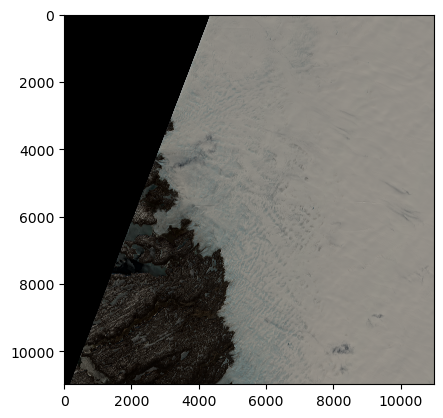

<Figure size 640x480 with 0 Axes>

In [12]:
# Let rasterio handle the scaling
show(rgb_stack, adjust=True)

In [43]:
item_id = np.char.decode(lake_zarr['source_items'].isel(time=0).data[0])
item_id

array('S2A_MSIL2A_20190501T145921_R125_T22WEA_20201006T083822',
      dtype='<U54')

In [44]:
out_meta= src.meta.copy()
out_meta["count"]=3

In [45]:
with rasterio.open(f"{item_id}.tif", "w",**out_meta) as dst:
    dst.write(rgb_stack)